In [1]:
import directional_tile_codes as dtc

In [2]:
from qldpc.codes import CSSCode
import matplotlib.pyplot as plt
from qldpc import circuits

# NESEN - (M,N) = (4,4)

In [3]:
word = dtc.DirectionalWord("NESEN")
code = dtc.DirTileCode(M=4, N=4, word=word)

layout edges:           72
X checks before prune:  32
Z checks before prune:  32
data after prune:       50
X checks after prune:   20
Z checks after prune:   28


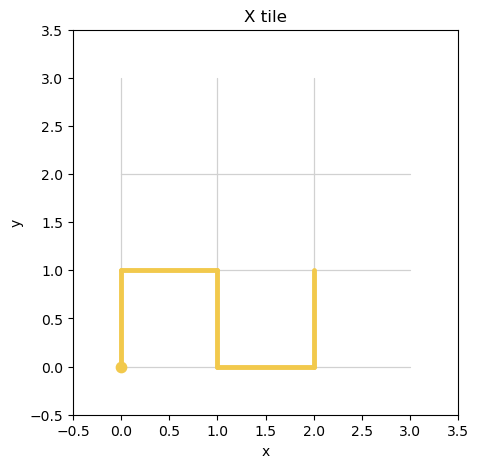

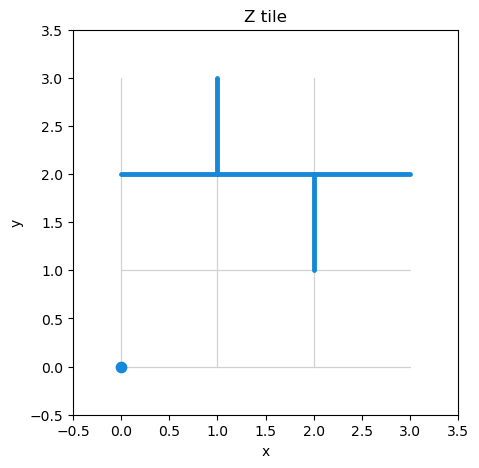

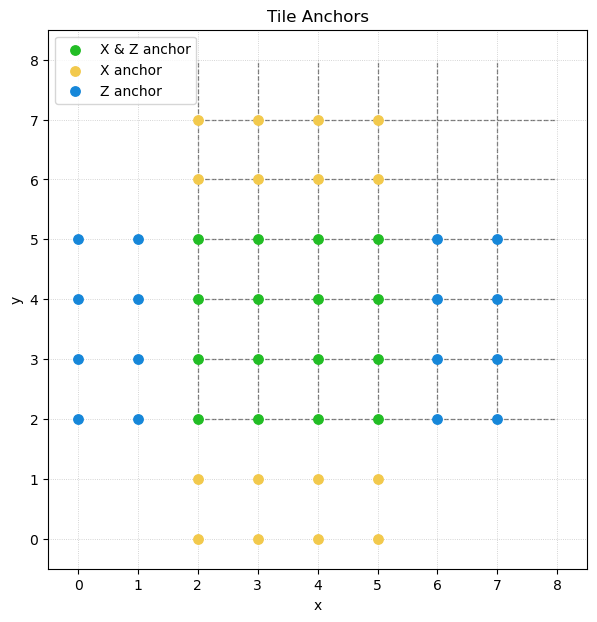

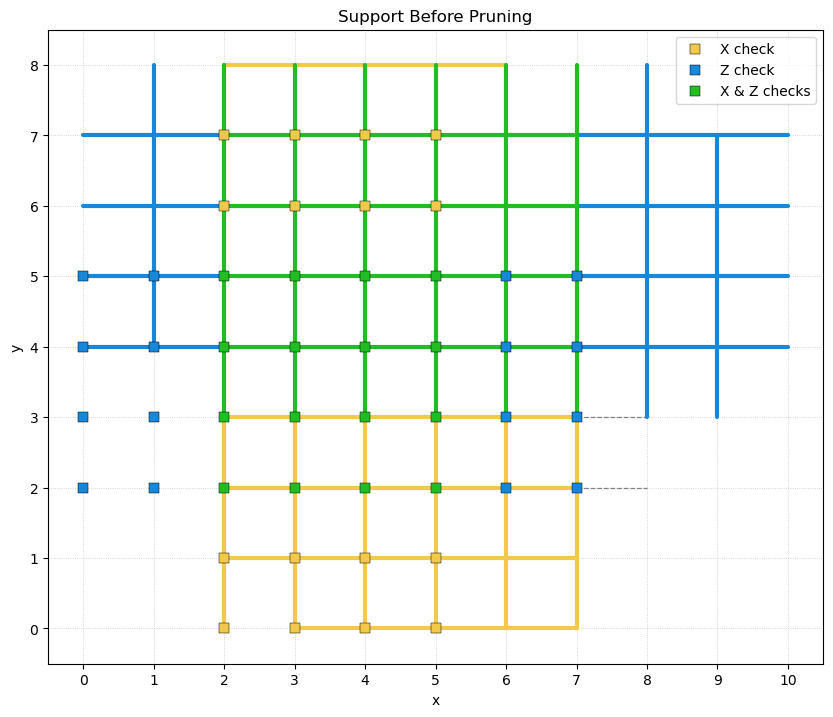

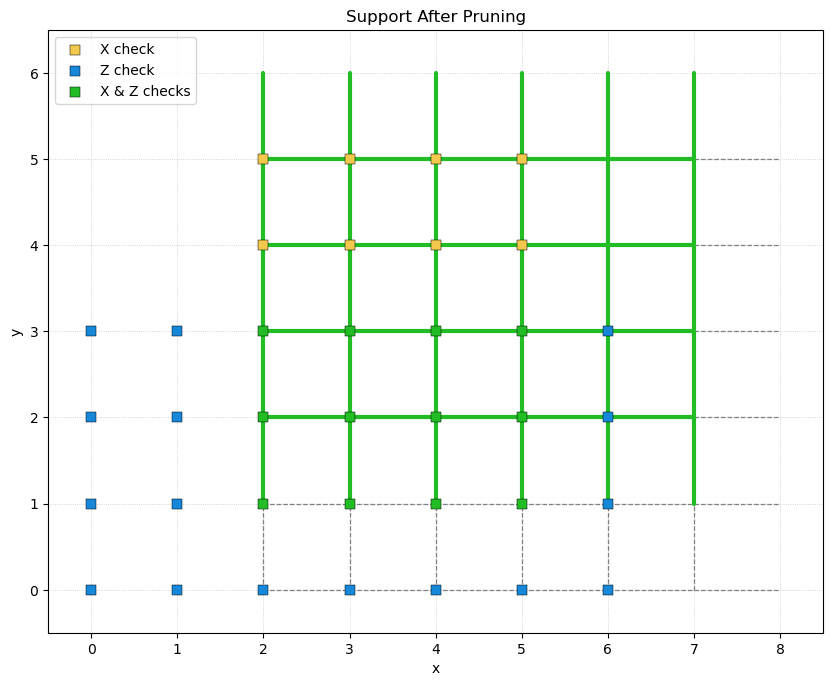

In [4]:
dtc.print_visualization_summary(code)

dtc.plot_x_tile(code)
plt.show()

dtc.plot_z_tile(code)
plt.show()

dtc.plot_anchors(code)
plt.show()

dtc.plot_support_before_prune(code)
plt.show()

dtc.plot_support_after_prune(code)
plt.show()

In [5]:
h_x, h_z = code.parity_check_matrices()
css_code = CSSCode(code_x=h_x, code_z=h_z)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [6]:
print("Is self dual: ", css_code.is_self_dual)
print()
print("Classical code of X-type parity checks:\n", css_code.code_x)
print("Classical code of Z-type parity checks:\n", css_code.code_z)
print()
# nx.draw(css_code.graph_x)
# nx.draw(css_code.graph_z)
# print()
print("Number of X-type parity checks: ", css_code.num_checks_x)
print("Number of Z-type parity checks: ", css_code.num_checks_z)
print()
print("Rank: ", css_code.rank)

Is self dual:  False

Classical code of X-type parity checks:
 ClassicalCode on 50 bits, with parity check matrix
[[1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 

### Logical Operators

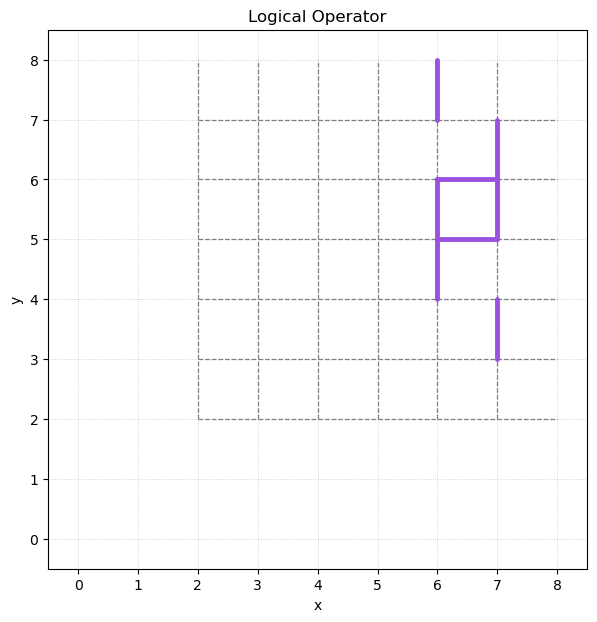

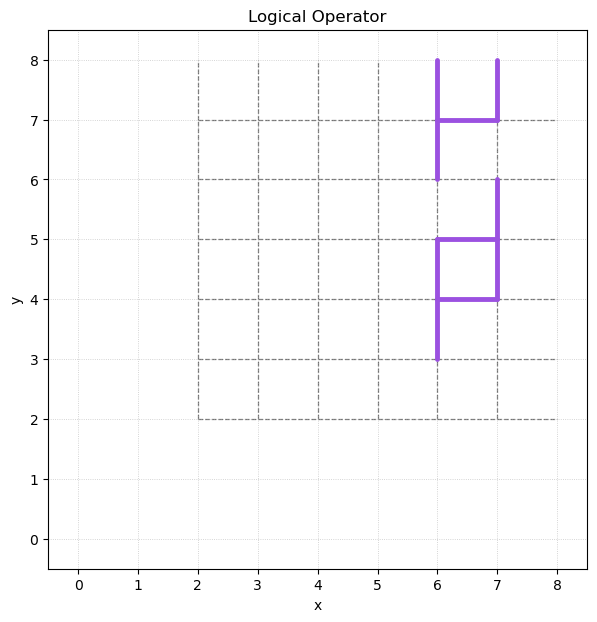

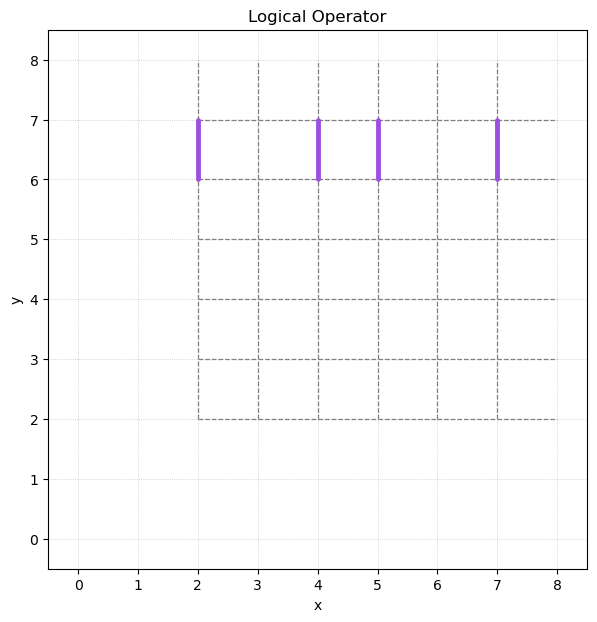

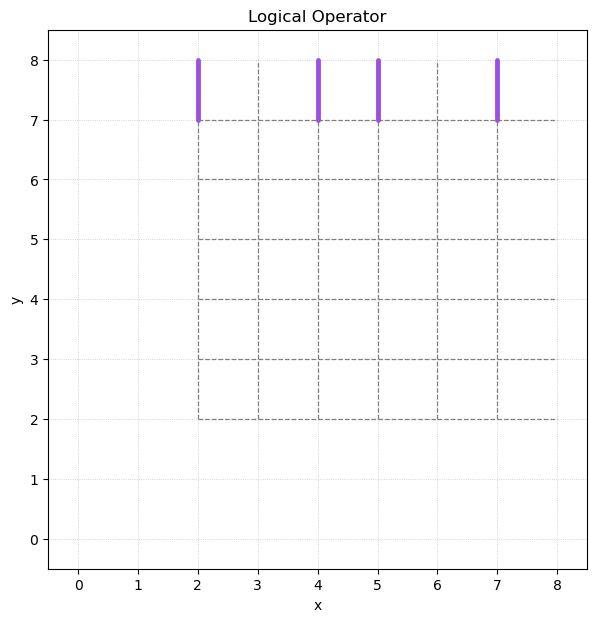

In [7]:
logical_ops = code.logical_ops
for op in logical_ops:
    dtc.plot_logical_operator(op, code=code)

### Logical Qubits

In [8]:
n = code.num_check_qubits
k = code.num_logical_qubits
print("Check qubits: ", n)
print("Logical qubits : ", k)

Check qubits:  50
Logical qubits :  2


### Distances

In [9]:
d = code.distance_exact
d_x = code.distance_x
d_z = code.distance_z

print("Exact distance: ", d)
print("Exact distance z: ", d_z)
print("Exact distance x: ", d_x)

Exact distance:  4
Exact distance z:  4
Exact distance x:  5


In [10]:
print(f"[[n, k, d]] = [[{n}, {k}, {d}]]")

[[n, k, d]] = [[50, 2, 4]]


### Circuit with Stim

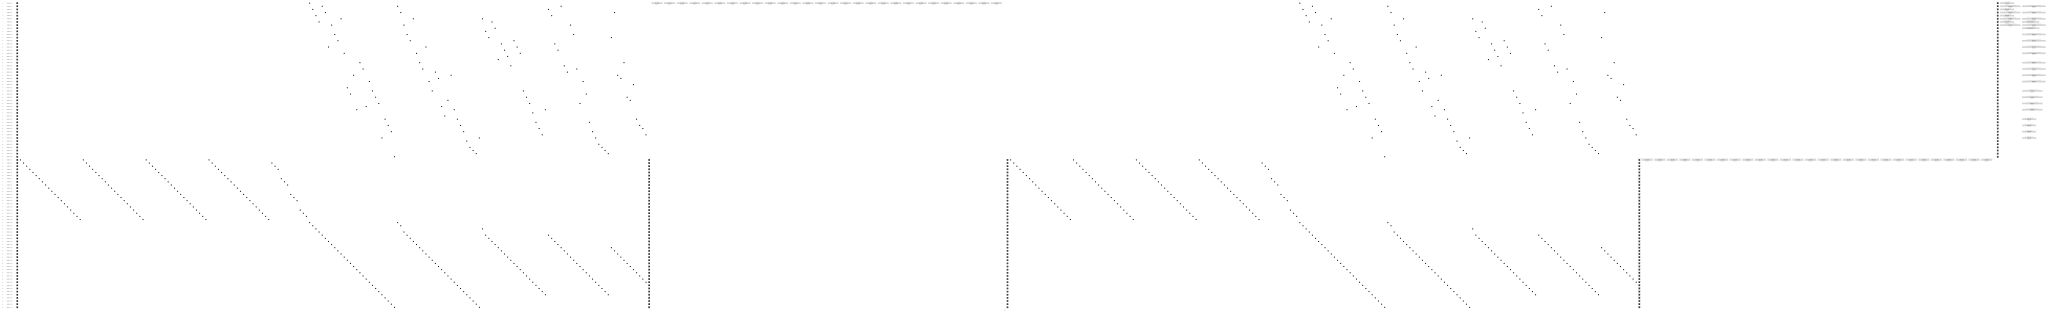

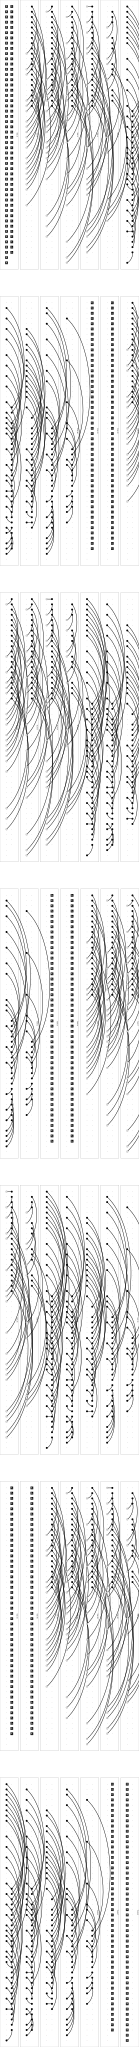

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Crumble</title>
    <style>
body {
    font-family: sans-serif;
}

#main-container {
    padding: 4px;
    display: flex;
    flex-direction: column;
    height: 100vh;
    box-sizing: border-box;
}

#cvn {
    width: 100%;
    flex: 1;
    min-height: 0;
    border: 1px solid black;
    margin: 0;
    padding: 0;
}

table {
    border: 1px solid black;
    margin: 10px;
    text-align: left;
    border-collapse: collapse;
}

table tr {
    border: 1px solid black;
}
table td {
    border: 1px solid black;
    padding-left: 5px;
    padding-right: 5px;
}
table th {
    border: 1px solid black;
    padding-left: 5px;
    padding-right: 5px;
}

.table-divider {
    border-top: 3px solid black;
}

#button-container {
    display: flex;
    flex-wrap: wrap;
    gap: 4px;
    align-items: flex-start;
}

.btn-group {
    display: flex;
    gap: 2px;
    flex-direction: column;
}

#examples-close-button {
    position: absolute;
    top: 10px;
    right: 10px;
    cursor: pointer;
    font-weight: 900;
}

#toolbox {
    width: 370px;
    height: 110px;
    border: 1px solid black;
    margin: 0;
    padding: 0;
}

#txtStimCircuit {
    width: 95vw;
    height: 300px;
    background-color: #FFFFB0;
}

#btnExport, #btnImport {
    background-color: red;
}
    </style>
    <link rel="shortcut icon" href="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAACAAAAAgCAYAAABzenr0AAABgWlDQ1BJQ0MgcHJvZmlsZQAAKJF9kTlIA0EUhj+j4kHEwhQiFluolQFREUuNgggRQlTwKtzdnJBdw27ExlKwDVh4NF6FjbW2FraCIHiAWFpZKdpIWN8kgQQxDgzz8c/8j/f+Ad9RxrTchgGw7JwTnQppC4tLWtMrrfiAAC266WbHI5EwNdfXPXXqvAuqWrXf/bnaYnHXhDpNeMzMOjnhVeGRjVxW8Z7qwkzpMeFz4X5HGhR+VLpR4jfFySKrpgk4c9EJ4YCwlqxio4rNlGMJDwv3xCxb6vsWShxTvKnYyqyb5T7VhP64PT+rdNndTDHNDBE0DNZJkyFHUE5bFJeo3Idq+LuK/oi4DHGlMcUxyRoWetGP+oPf2bqJocFSJX8IGl8876MXmnagkPe872PPK5xA/TNc2RX/2hGMfoqer2g9h9C+BRfXFc3Yhctt6HzK6o5elOpl+xIJeD+Tb1qEjltoXS7lVr7n9AHmJKvwDewfQF9Saq/UmLu5Ord/35Tz+wHVp3JoxsjWZAAAAAlwSFlzAAAuIwAALiMBeKU/dgAAAAd0SU1FB+YKAhYQLxXIct8AAAAZdEVYdENvbW1lbnQAQ3JlYXRlZCB3aXRoIEdJTVBXgQ4XAAAAx0lEQVRYw+2XwQ7EIAhEB+N/E76cnkgIa6OuWTFxvTWxdRgKDwmAYu+i+KDKPP62CJjHNYsQ7Psk8iGk7AxdmeGC1e0CvBBbKQK8ljQB5kK2AxcLsJLMdoBKZvQAULMOtk5IR7Dg294+yw4RymUBs3qQ5bHAO34vC8yFPwvSBFhJ3skC35Bq1sHHsKDGKfUX94J46HllGDjd5XnI5WjOXwXQSg5X95eXaaU3zXSjG3XJ79LW1ak1RsX9/qdsldqsPTppo66k6QGRuElWZ7d4CQAAAABJRU5ErkJggg==">
</head>
<body id="main-container" style="margin: 0">
    <div style="display: inline-block">
        <div>
            <div style="display: inline-block">
                Crumble is a prototype stabilizer circuit editor.<br>
                <br>
                <a href="https://github.com/quantumlib/Stim/blob/main/glue/crumble/README.md">Read the manual</a>
                <br>
                <br>
                <button id="btnShowExamples">Show Example Circuits</button><br>
                <br>
            </div>
            <div style="display: inline-block">
                <canvas id="toolbox">
                </canvas>
            </div>
        </div>
        <div id="button-container">
            <div class="btn-group">
                <button id="btnShowHideImportExport">Show Import/Export</button>
                <button id="clear">Clear All</button>
            </div>
            <div class="btn-group">
                <button id="btnClearMarkers">Clear All Pauli Marks</button>
                <button id="btnClearSelectedMarkers">Clear Selected Marks (space)</button>
            </div>
            <div class="btn-group">
                <button id="btnRedo">Redo (ctrl+Y)</button>
                <button id="btnUndo">Undo (ctrl+Z)</button>
            </div>
            <div class="btn-group">
                <button id="btnNextLayer">Next Layer (e)</button>
                <button id="btnPrevLayer">Prev Layer (q)</button>
            </div>
            <div class="btn-group">
                <button id="btnRotate45">Rotate 45 Clockwise ↻ (t)</button>
               
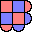

In [ ]:
circuit = circuits.get_memory_experiment(
    css_code,
    basis="Z",
    num_rounds=4,
    noise_model=None,
)
display(circuit.diagram("timeline-svg"))
display(circuit.diagram("timeslice-svg"))
display(circuit.diagram("interactive"))

# qubit coords to assigne coordinates
# detslice-svg

# NESEN - (M,N) = (22,3)

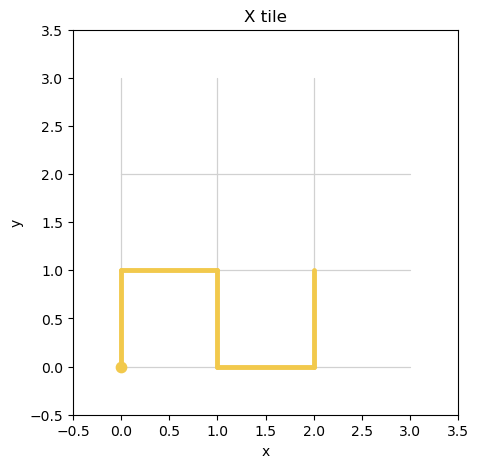

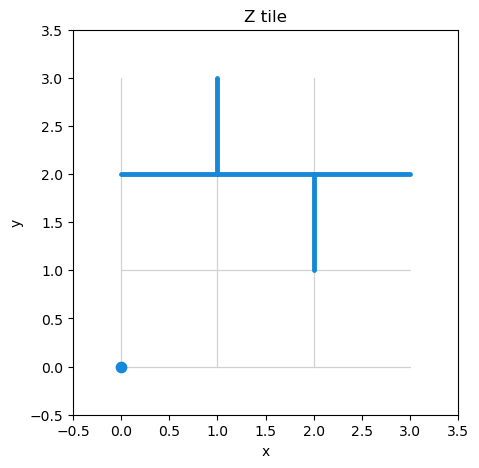

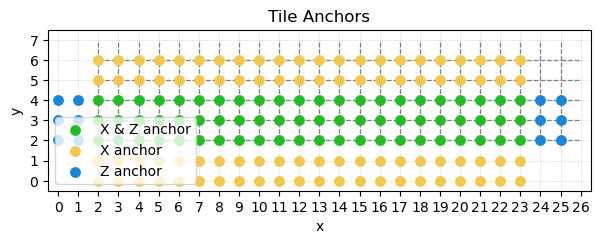

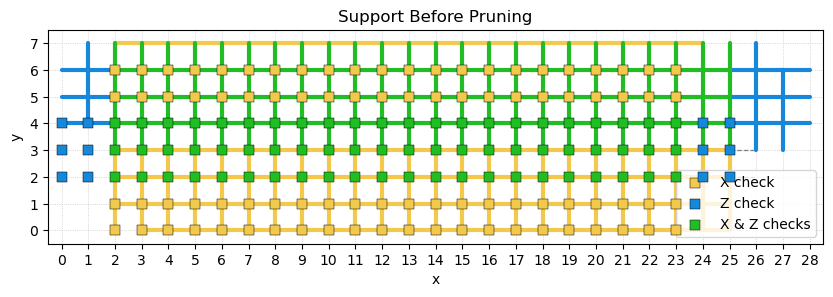

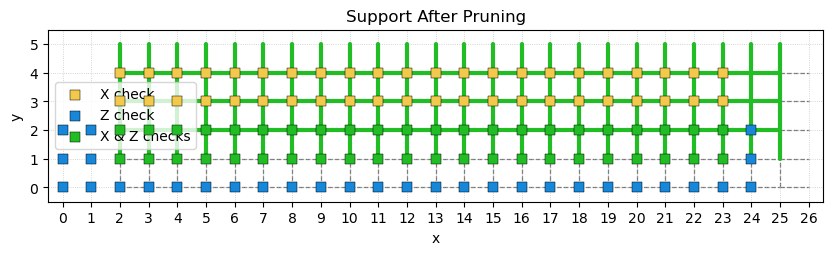

In [12]:
word = dtc.DirectionalWord("NESEN")
code = dtc.DirTileCode(M=22, N=3, word=word)

dtc.plot_x_tile(code)
plt.show()

dtc.plot_z_tile(code)
plt.show()

dtc.plot_anchors(code)
plt.show()

dtc.plot_support_before_prune(code)
plt.show()

dtc.plot_support_after_prune(code)
plt.show()

In [13]:
h_x, h_z = code.parity_check_matrices()
css_code = CSSCode(code_x=h_x, code_z=h_z)

In [14]:
d = css_code.get_distance_exact()
print(d)

4


In [15]:
d_bound = css_code.get_distance_bound(backend="gap")
print(d_bound)

4


In [16]:
d_bound_x = css_code.get_distance_bound(pauli="X", backend="gap")
print(d_bound_x)

4


In [17]:
d_bound_z = css_code.get_distance_bound(pauli="Z", backend="gap", num_trials=500)
print(d_bound_z)

16
